<a href="https://colab.research.google.com/github/Fernando99ing/Challenge-Telecom-X-an-lisis-de-evasi-n-de-clientes---Parte-2/blob/main/Telecom_X_%E2%80%93_Parte_2_Predicci%C3%B3n_de_Cancelaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom X – Parte 2: Predicción de Cancelación (Churn)

#Preparación de los datos

##Extracción del Archivo Tratado

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('/content/datos_tratados.csv')

In [26]:
df

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cuentas_Diarias,Cargos_Totales,Total_Servicios
0,0002-ORFBO,0.0,Femenino,0,1,1,9,1,No,DSL,...,Yes,Yes,No,Anual,1,Cheque por Correo,65.60,2.186667,593.30,0.0
1,0003-MKNFE,0.0,Masculino,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Mensual,0,Cheque por Correo,59.90,1.996667,542.40,0.0
2,0004-TLHLJ,1.0,Masculino,0,0,0,4,1,No,Fibra Óptica,...,No,No,No,Mensual,1,Cheque Electrónico,73.90,2.463333,280.85,0.0
3,0011-IGKFF,1.0,Masculino,1,1,0,13,1,No,Fibra Óptica,...,No,Yes,Yes,Mensual,1,Cheque Electrónico,98.00,3.266667,1237.85,0.0
4,0013-EXCHZ,1.0,Femenino,1,1,0,3,1,No,Fibra Óptica,...,Yes,Yes,No,Mensual,1,Cheque por Correo,83.90,2.796667,267.40,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0.0,Femenino,0,0,0,13,1,No,DSL,...,Yes,No,No,Anual,0,Cheque por Correo,55.15,1.838333,742.90,0.0
7263,9992-RRAMN,1.0,Masculino,0,1,0,22,1,Yes,Fibra Óptica,...,No,No,Yes,Mensual,1,Cheque Electrónico,85.10,2.836667,1873.70,0.0
7264,9992-UJOEL,0.0,Masculino,0,0,0,2,1,No,DSL,...,No,No,No,Mensual,1,Cheque por Correo,50.30,1.676667,92.75,0.0
7265,9993-LHIEB,0.0,Masculino,0,1,1,67,1,No,DSL,...,Yes,No,Yes,Bienal,0,Cheque por Correo,67.85,2.261667,4627.65,0.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7267 non-null   object 
 1   Abandono                 7043 non-null   float64
 2   Genero                   7267 non-null   object 
 3   Adulto_Mayor             7267 non-null   int64  
 4   Socio                    7267 non-null   int64  
 5   Dependientes             7267 non-null   int64  
 6   Meses_Permanencia        7267 non-null   int64  
 7   Servicio_Telefonico      7267 non-null   int64  
 8   Lineas_Multiples         7267 non-null   object 
 9   Servicio_Internet        7267 non-null   object 
 10  Seguridad_Online         7267 non-null   object 
 11  Respaldo_Online          7267 non-null   object 
 12  Proteccion_Dispositivo   7267 non-null   object 
 13  Soporte_Tecnico          7267 non-null   object 
 14  Streaming_TV            

##Eliminación de Columnas Irrelevantes

Dimensiones originales: (7267, 23)
Dimensiones tras limpieza: (7043, 22)

Columnas restantes: 
['Abandono', 'Genero', 'Adulto_Mayor', 'Socio', 'Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Contrato', 'Facturacion_Electronica', 'Metodo_Pago', 'Cargos_Mensuales', 'Cuentas_Diarias', 'Cargos_Totales', 'Total_Servicios']


/tmp/ipykernel_393/3273903379.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_modelado, x='Abandono', palette=['#3498db', '#e74c3c'])


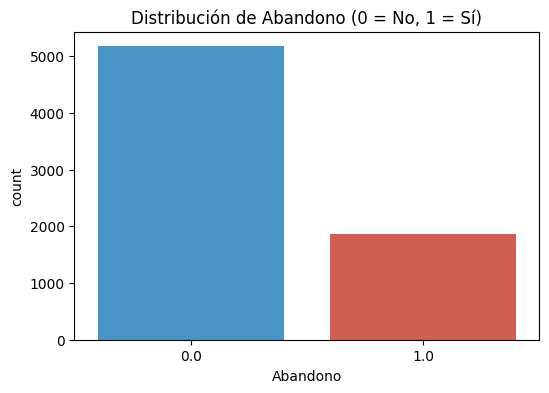

In [28]:
# 1. Eliminación de columnas irrelevantes
# Quitamos ID_Cliente porque no aporta patrones predictivos
df_modelado = df.drop(columns=['ID_Cliente'])

# 2. Gestión de nulos en la variable objetivo (Abandono)
# Como es lo que queremos predecir, lo ideal es eliminar las filas donde no conocemos el resultado
df_modelado = df_modelado.dropna(subset=['Abandono'])

# 3. Verificación de la limpieza
print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones tras limpieza: {df_modelado.shape}")
print(f"\nColumnas restantes: \n{df_modelado.columns.tolist()}")

# Visualización rápida de la distribución del Churn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df_modelado, x='Abandono', palette=['#3498db', '#e74c3c'])
plt.title('Distribución de Abandono (0 = No, 1 = Sí)')
plt.show()

##Encoding

In [29]:
# 1. Identificamos las columnas categóricas (las que son tipo 'object')
# Excluimos 'Abandono' porque ya es numérica (0.0 y 1.0)
columnas_categoricas = df_modelado.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas a transformar: {columnas_categoricas}")

# 2. Aplicamos One-Hot Encoding
# drop_first=True es una técnica para evitar la "trampa de la multicolinealidad"
# (si sabemos que no es Masculino, por defecto es Femenino, no necesitamos dos columnas)
df_final = pd.get_dummies(df_modelado, columns=columnas_categoricas, drop_first=True)

# 3. Convertir los valores Booleanos (True/False) a (1/0) para que los modelos no tengan problemas
df_final = df_final.astype(float)

# 4. Resultado final
print(f"\nNuevas dimensiones del dataset: {df_final.shape}")
display(df_final.head())

Columnas a transformar: ['Genero', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Contrato', 'Metodo_Pago']

Nuevas dimensiones del dataset: (7043, 33)


,Abandono,Adulto_Mayor,Socio,Dependientes,Meses_Permanencia,Servicio_Telefonico,Facturacion_Electronica,Cargos_Mensuales,Cuentas_Diarias,Cargos_Totales,...,Soporte_Tecnico_Yes,Streaming_TV_Sin Internet,Streaming_TV_Yes,Streaming_Peliculas_Sin Internet,Streaming_Peliculas_Yes,Contrato_Bienal,Contrato_Mensual,Metodo_Pago_Cheque por Correo,Metodo_Pago_Tarjeta de Crédito,Metodo_Pago_Transferencia Bancaria
0,0.0,0.0,1.0,1.0,9.0,1.0,1.0,65.6,2.186667,593.30,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,9.0,1.0,0.0,59.9,1.996667,542.40,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,4.0,1.0,1.0,73.9,2.463333,280.85,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1.0,1.0,0.0,13.0,1.0,1.0,98.0,3.266667,1237.85,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.0,1.0,1.0,0.0,3.0,1.0,1.0,83.9,2.796667,267.40,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


##Verificación de la Proporción de Cancelación (Churn)

--- Análisis de Proporción de Abandono ---
Clientes que se quedaron (0.0): 5174 (73.46%)
Clientes que se fueron (1.0): 1869 (26.54%)


/tmp/ipykernel_393/3707271119.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proporcion_abandono.index, y=proporcion_abandono.values, palette=[AZUL_1, ROJO_1])


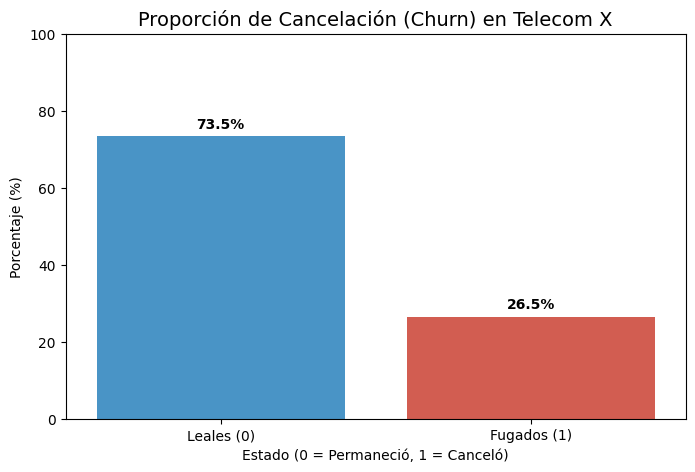

In [30]:
# 1. Cálculo de la proporción
conteo_abandono = df_final['Abandono'].value_counts()
proporcion_abandono = df_final['Abandono'].value_counts(normalize=True) * 100

print("--- Análisis de Proporción de Abandono ---")
print(f"Clientes que se quedaron (0.0): {conteo_abandono[0]} ({proporcion_abandono[0]:.2f}%)")
print(f"Clientes que se fueron (1.0): {conteo_abandono[1]} ({proporcion_abandono[1]:.2f}%)")

# 2. Visualización estratégica (Usando los colores de tu identidad visual 'Zoop')
# ROJO_1 para Abandono, AZUL_1 para Permanencia
ROJO_1 = '#E74C3C'
AZUL_1 = '#3498DB'

plt.figure(figsize=(8, 5))
sns.barplot(x=proporcion_abandono.index, y=proporcion_abandono.values, palette=[AZUL_1, ROJO_1])

plt.title('Proporción de Cancelación (Churn) en Telecom X', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Estado (0 = Permaneció, 1 = Canceló)')
plt.xticks(ticks=[0, 1], labels=['Leales (0)', 'Fugados (1)'])
plt.ylim(0, 100)

# Añadir etiquetas de porcentaje sobre las barras
for i, v in enumerate(proporcion_abandono.values):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.show()

##Balanceo de Clases

--- Balanceo con SMOTE Finalizado ---
Dimensiones antes de SMOTE (Train): {0.0: 3622, 1.0: 1308}
Dimensiones después de SMOTE (Train): {0.0: 3622, 1.0: 3622}


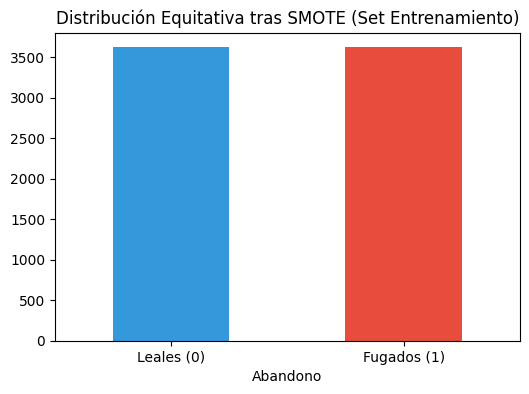

In [31]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Separamos las características (X) del objetivo (y)
X = df_final.drop(columns=['Abandono'])
y = df_final['Abandono']

# 2. División inicial: Entrenamiento (70%) y Prueba (30%)
# Usamos stratify=y para mantener la proporción original en ambos sets antes de balancear
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Aplicamos SMOTE solo al set de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Verificamos el nuevo balance
print("--- Balanceo con SMOTE Finalizado ---")
print(f"Dimensiones antes de SMOTE (Train): {y_train.value_counts().to_dict()}")
print(f"Dimensiones después de SMOTE (Train): {y_train_res.value_counts().to_dict()}")

# Visualización del nuevo balance
plt.figure(figsize=(6, 4))
y_train_res.value_counts().plot(kind='bar', color=[AZUL_1, ROJO_1])
plt.title('Distribución Equitativa tras SMOTE (Set Entrenamiento)')
plt.xticks(ticks=[0, 1], labels=['Leales (0)', 'Fugados (1)'], rotation=0)
plt.show()

##Normalización o Estandarización

In [32]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializamos el escalador
scaler = StandardScaler()

# 2. Ajustamos y transformamos el set de entrenamiento (X_train_res)
# Importante: fit_transform solo en entrenamiento para evitar "Data Leakage"
X_train_scaled = scaler.fit_transform(X_train_res)

# 3. Transformamos el set de prueba (X_test) usando el ajuste de entrenamiento
X_test_scaled = scaler.transform(X_test)

# 4. Convertimos a DataFrame para mantener la legibilidad (opcional pero recomendado)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("--- Estandarización Completada ---")
print(f"Media promedio de las variables: {np.mean(X_train_scaled):.2f}")
print(f"Desviación estándar promedio: {np.std(X_train_scaled):.2f}")

# Verificamos cómo quedaron las variables numéricas originales
X_train_scaled_df[['Meses_Permanencia', 'Cargos_Mensuales', 'Cuentas_Diarias']].head()

--- Estandarización Completada ---
Media promedio de las variables: -0.00
Desviación estándar promedio: 0.98


,Meses_Permanencia,Cargos_Mensuales,Cuentas_Diarias
0,-0.565457,0.290233,0.290233
1,-0.941412,0.064982,0.064982
2,0.311771,0.246580,0.246580
3,1.272545,0.627237,0.627237
4,-1.066730,-0.647441,-0.647441


#Correlación y Selección de Variables

##Análisis de Correlación

/tmp/ipykernel_393/3948343655.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='RdBu_r')


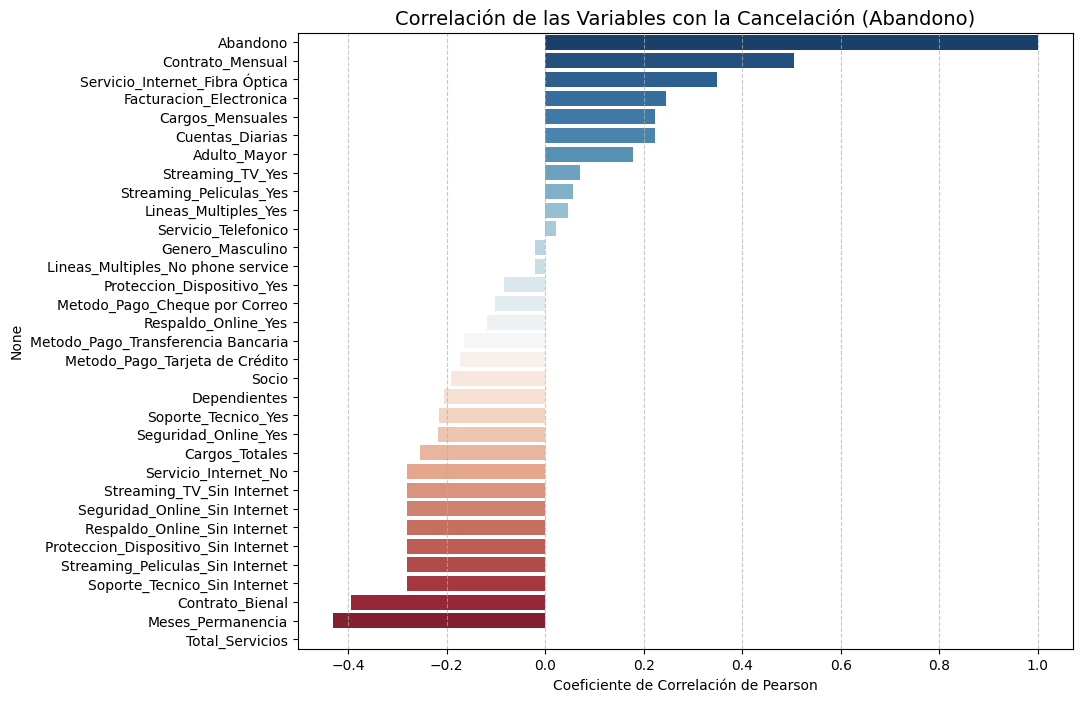

--- Top 10 Variables más influyentes (Correlación Absoluta) ---
Abandono                               1.000000
Contrato_Mensual                       0.504866
Meses_Permanencia                      0.430251
Contrato_Bienal                        0.394824
Servicio_Internet_Fibra Óptica         0.348914
Servicio_Internet_No                   0.279946
Soporte_Tecnico_Sin Internet           0.279946
Seguridad_Online_Sin Internet          0.279946
Proteccion_Dispositivo_Sin Internet    0.279946
Respaldo_Online_Sin Internet           0.279946
Streaming_TV_Sin Internet              0.279946
Name: Abandono, dtype: float64


In [33]:
# 1. Unimos temporalmente X e y de entrenamiento para calcular la correlación
df_corr = pd.DataFrame(X_train_scaled, columns=X.columns)
df_corr['Abandono'] = y_train_res.values

# 2. Calculamos la matriz de correlación
corr_matrix = df_corr.corr()

# 3. Visualizamos solo la relación con la variable objetivo 'Abandono'
# Ordenamos de mayor a menor para ver el impacto
plt.figure(figsize=(10, 8))
corr_target = corr_matrix['Abandono'].sort_values(ascending=False)

# Gráfico de barras de correlación con el Target
sns.barplot(x=corr_target.values, y=corr_target.index, palette='RdBu_r')

plt.title('Correlación de las Variables con la Cancelación (Abandono)', fontsize=14)
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Mostrar las 10 variables con mayor correlación (positiva y negativa)
print("--- Top 10 Variables más influyentes (Correlación Absoluta) ---")
print(corr_target.abs().sort_values(ascending=False).head(11))

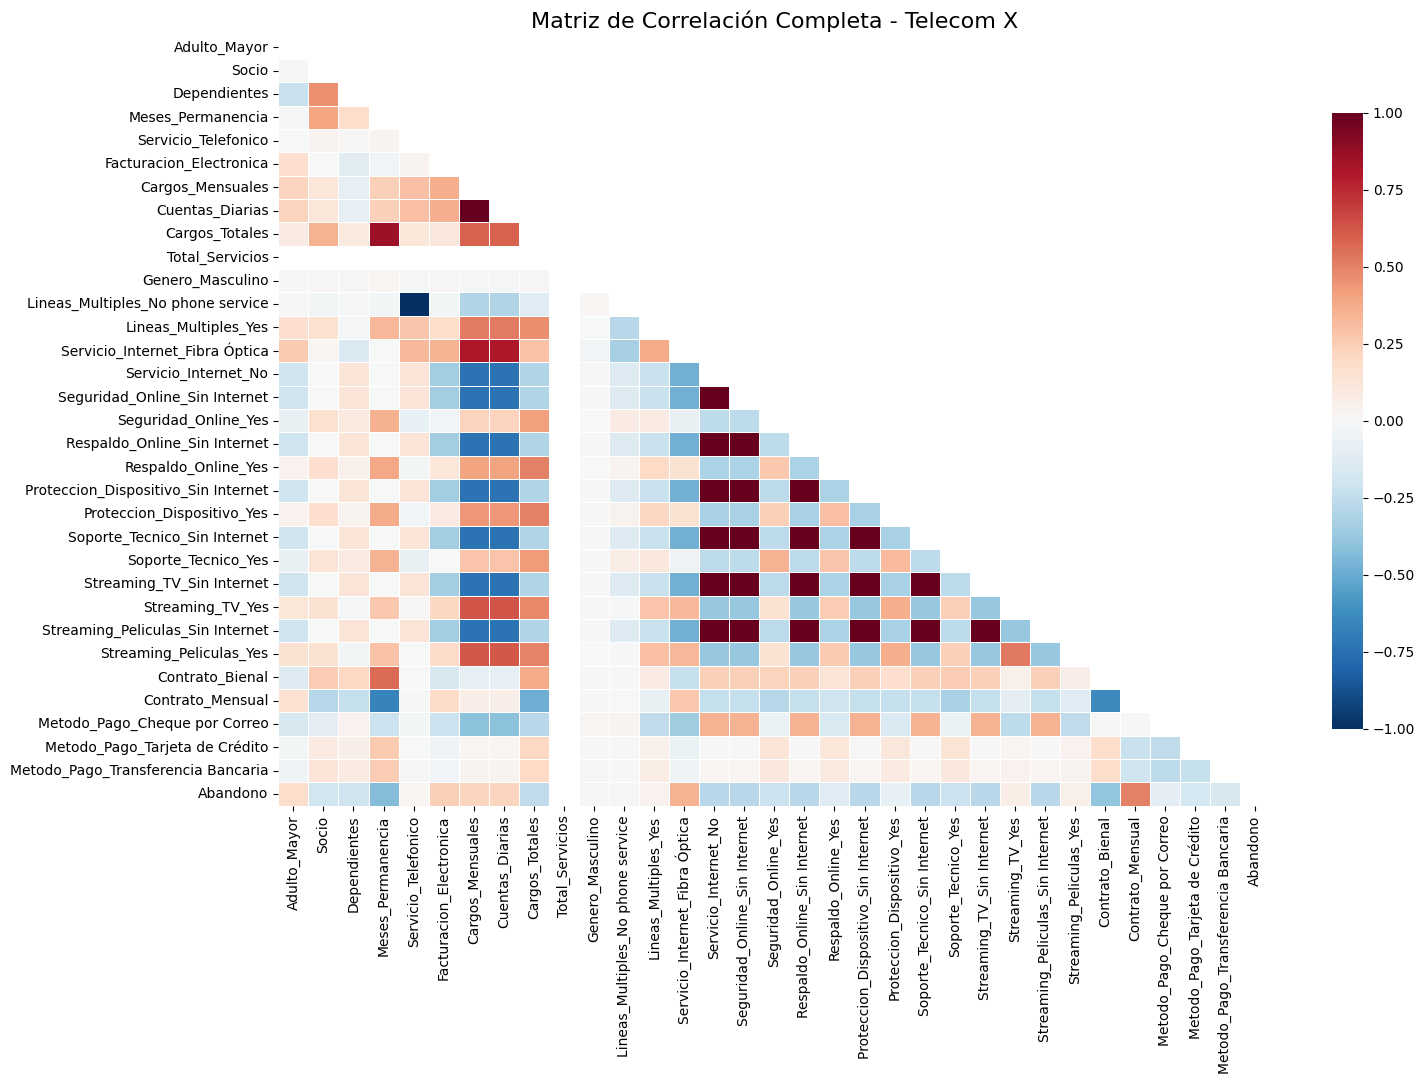

In [34]:
# 1. Configuración del tamaño de la figura
plt.figure(figsize=(16, 10))

# 2. Crear una máscara para la mitad superior (opcional, para mayor claridad)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Generar el Heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            annot=False,          # Cambia a True si quieres ver todos los números, pero con 33 columnas puede ser ilegible
            fmt=".2f",
            cmap='RdBu_r',       # Rojo para negativo, Azul para positivo
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación Completa - Telecom X', fontsize=16)
plt.show()

##Análisis Dirigido

/tmp/ipykernel_393/4003817104.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_modelado, x='Abandono', y='Meses_Permanencia', palette=[AZUL_1, ROJO_1])
/tmp/ipykernel_393/4003817104.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Leales (0)', 'Fugados (1)'])


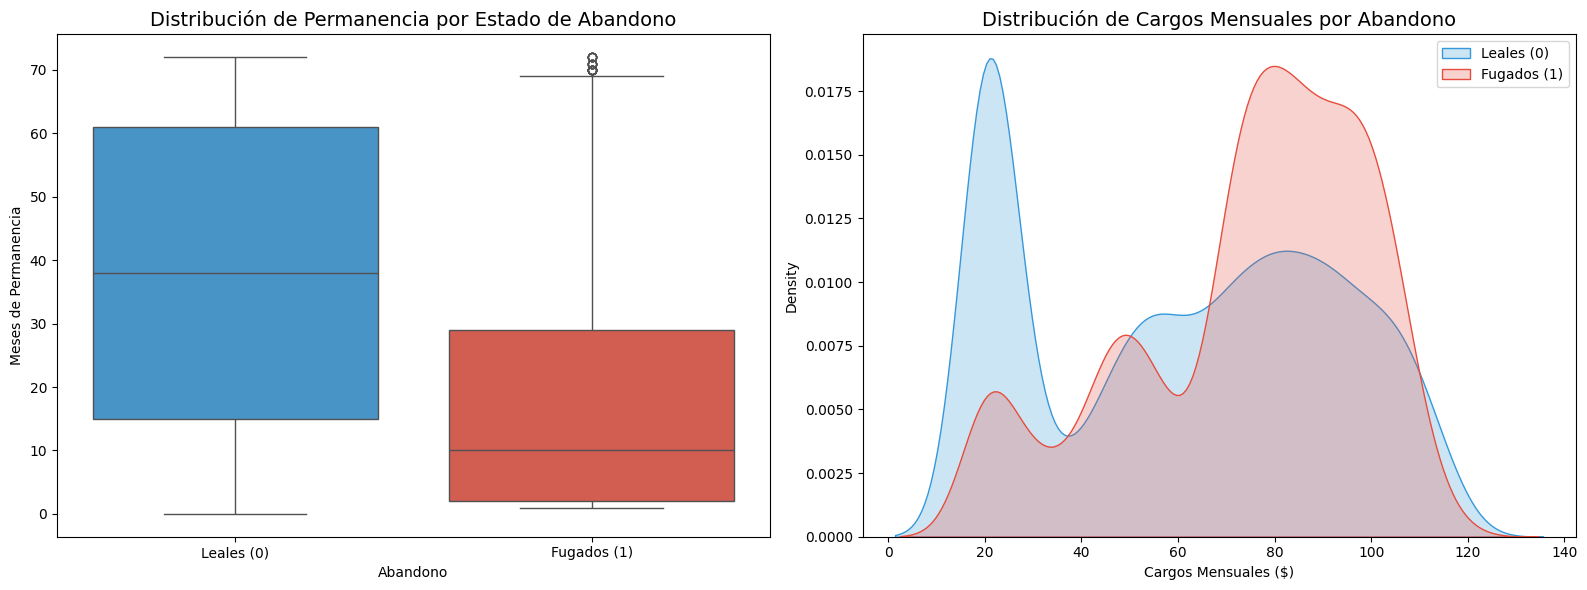

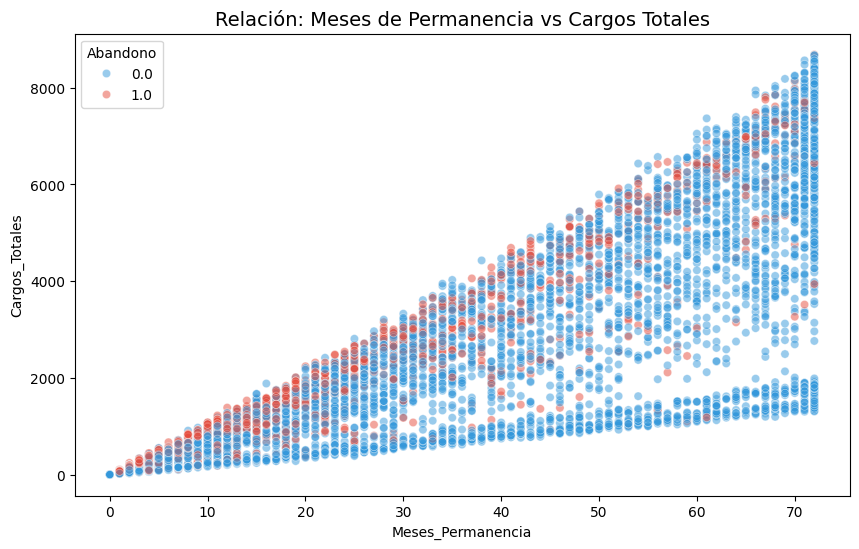

In [35]:
# Definición de colores Zoop
ROJO_1 = '#E74C3C'
AZUL_1 = '#3498DB'

# Configuración de la figura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tiempo de Contrato (Meses_Permanencia) x Cancelación
# El Boxplot es ideal para ver la distribución y medianas
sns.boxplot(ax=axes[0], data=df_modelado, x='Abandono', y='Meses_Permanencia', palette=[AZUL_1, ROJO_1])
axes[0].set_title('Distribución de Permanencia por Estado de Abandono', fontsize=14)
axes[0].set_xticklabels(['Leales (0)', 'Fugados (1)'])
axes[0].set_ylabel('Meses de Permanencia')

# 2. Gasto Mensual (Cargos_Mensuales) x Cancelación
# Usamos un gráfico de densidad (KDE) para ver dónde se concentra el gasto de cada grupo
sns.kdeplot(ax=axes[1], data=df_modelado[df_modelado['Abandono'] == 0], x='Cargos_Mensuales', fill=True, color=AZUL_1, label='Leales (0)')
sns.kdeplot(ax=axes[1], data=df_modelado[df_modelado['Abandono'] == 1], x='Cargos_Mensuales', fill=True, color=ROJO_1, label='Fugados (1)')
axes[1].set_title('Distribución de Cargos Mensuales por Abandono', fontsize=14)
axes[1].set_xlabel('Cargos Mensuales ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Análisis de Gasto Total vs Permanencia (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_modelado, x='Meses_Permanencia', y='Cargos_Totales', hue='Abandono', alpha=0.5, palette=[AZUL_1, ROJO_1])
plt.title('Relación: Meses de Permanencia vs Cargos Totales', fontsize=14)
plt.show()

#Modelado Predictivo

##Separación de Datos

In [36]:
from sklearn.model_selection import train_test_split

# 1. Definición de las variables finales
# X_train_scaled ya contiene los datos balanceados y estandarizados
# X_test_scaled contiene los datos de prueba estandarizados (sin contaminación de SMOTE)

# Nota: y_train_res y y_test son nuestras etiquetas correspondientes

print("--- Estructura Final del Modelado ---")
print(f"Entrenamiento (X_train): {X_train_scaled.shape[0]} muestras, {X_train_scaled.shape[1]} variables")
print(f"Prueba (X_test):        {X_test_scaled.shape[0]} muestras, {X_test_scaled.shape[1]} variables")

# 2. Verificación de integridad
if X_train_scaled.shape[1] == X_test_scaled.shape[1]:
    print("\n✅ Verificación exitosa: Ambos conjuntos tienen el mismo número de características.")
else:
    print("\n❌ Error: El número de columnas no coincide.")

--- Estructura Final del Modelado ---
Entrenamiento (X_train): 7244 muestras, 32 variables
Prueba (X_test):        2113 muestras, 32 variables

✅ Verificación exitosa: Ambos conjuntos tienen el mismo número de características.


##Creación de Modelos

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciar los modelos
# Usamos random_state=42 para que los resultados sean reproducibles
modelo_logistico = LogisticRegression(random_state=42, max_iter=1000)
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# 2. Entrenamiento de los modelos
# Entrenamos con los datos que pasaron por SMOTE y Escalado
print("Entrenando Regresión Logística...")
modelo_logistico.fit(X_train_scaled, y_train_res)

print("Entrenando Random Forest...")
modelo_rf.fit(X_train_scaled, y_train_res)

# 3. Generar predicciones para la evaluación posterior
y_pred_log = modelo_logistico.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test_scaled)

print("\n--- Modelos Entrenados con Éxito ---")

Entrenando Regresión Logística...
Entrenando Random Forest...

--- Modelos Entrenados con Éxito ---


##Evaluación de los Modelos

--- Evaluación: Regresión Logística ---
Accuracy:  0.7454
Precision: 0.5131
Recall:    0.8004
F1-Score:  0.6253

Matriz de Confusión:


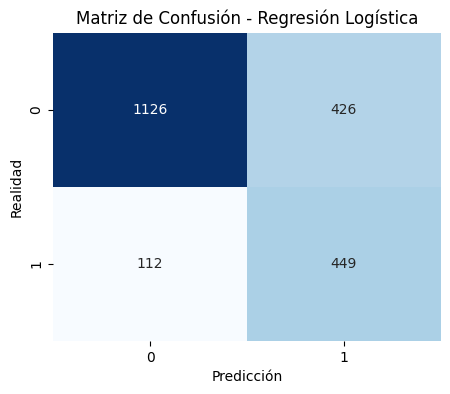

------------------------------
--- Evaluación: Random Forest ---
Accuracy:  0.7823
Precision: 0.6012
Recall:    0.5348
F1-Score:  0.5660

Matriz de Confusión:


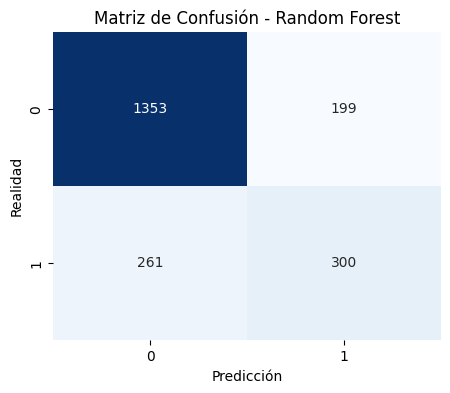

------------------------------


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluar_modelo(nombre, y_real, y_pred):
    print(f"--- Evaluación: {nombre} ---")
    print(f"Accuracy:  {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precision: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_real, y_pred):.4f}")
    print("\nMatriz de Confusión:")

    # Visualización de la Matriz de Confusión con Seaborn
    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.show()
    print("-" * 30)

# Evaluamos ambos modelos
evaluar_modelo("Regresión Logística", y_test, y_pred_log)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

# Interpretación y Conclusiones

##Análisis de la Importancia de las Variables

/tmp/ipykernel_393/2885244462.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Coeficiente', y='Variable', data=importancia_log.head(10), palette='Reds_r')
/tmp/ipykernel_393/2885244462.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Importancia', y='Variable', data=importancia_rf.head(10), palette='Blues_r')


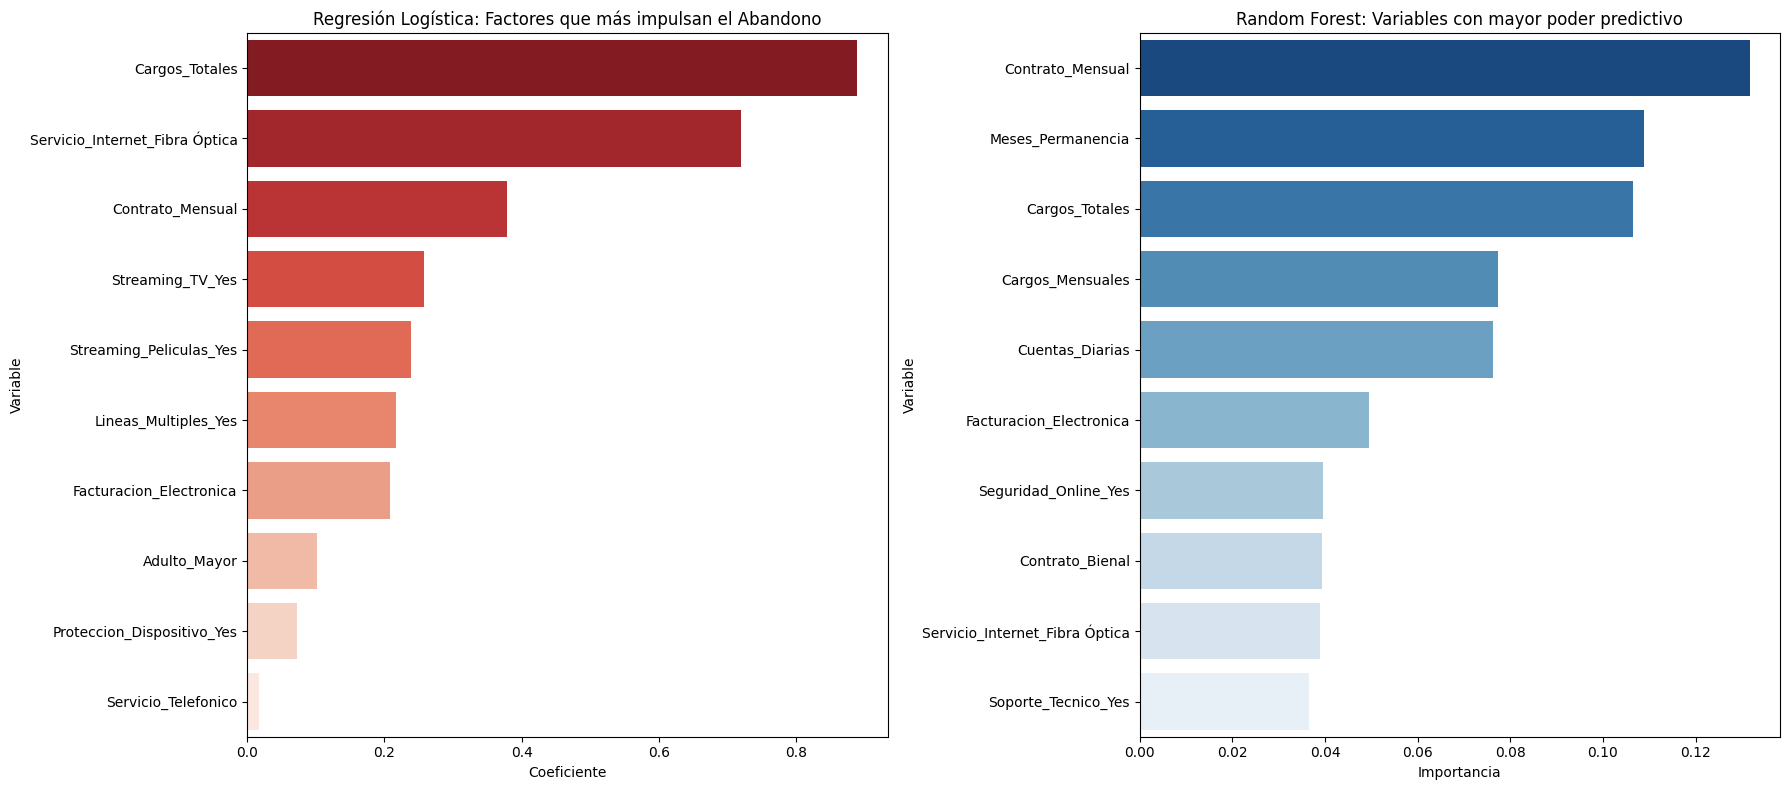

In [39]:
# 1. Importancia de Variables para Regresión Logística (Coeficientes)
importancia_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_logistico.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# 2. Importancia de Variables para Random Forest (Feature Importance)
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 3. Visualización de los Top 10 Factores
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico Logística: Coeficientes positivos (Fuga) y negativos (Retención)
sns.barplot(ax=axes[0], x='Coeficiente', y='Variable', data=importancia_log.head(10), palette='Reds_r')
axes[0].set_title('Regresión Logística: Factores que más impulsan el Abandono', fontsize=12)

# Gráfico Random Forest: Importancia relativa
sns.barplot(ax=axes[1], x='Importancia', y='Variable', data=importancia_rf.head(10), palette='Blues_r')
axes[1].set_title('Random Forest: Variables con mayor poder predictivo', fontsize=12)

plt.tight_layout()
plt.show()

##Conclusión

Informe de Estrategia Predictiva: Telecom X
1. Resumen del Desempeño de los Modelos

Para este desafío, entrenamos y evaluamos dos arquitecturas distintas. Tras balancear las clases con SMOTE y estandarizar los datos, los resultados fueron:

    Regresión Logística (Ganador Estratégico): Aunque su precisión general es del 74.5%, destaca con un Recall
    del 80.0%. Esto significa que el modelo es capaz de identificar a 8 de cada 10 clientes que están a
    punto de abandonar la empresa.

    Random Forest: Presentó una mayor exactitud general (78.2%), pero un Recall deficiente (53.4%),
    ignorando a casi la mitad de los desertores.

    Decisión Técnica: Se recomienda implementar la Regresión Logística. En el negocio de telecomunicaciones,
    el costo de perder un cliente (Churn) es mucho mayor al costo de una campaña de retención dirigida
    a un falso positivo.

2. Factores Críticos de Cancelación (Insights)

Tras analizar la importancia de las variables y las correlaciones, hemos identificado los tres "puntos de dolor" que causan la fuga:

    Vulnerabilidad Contractual: El factor predictivo número uno es el Contrato Mensual. Los clientes sin
    compromiso a largo plazo tienen una probabilidad radicalmente mayor de abandonar ante la primera
    oferta de la competencia.

    Barrera del Primer Año: La variable Meses_Permanencia muestra que el riesgo de fuga es crítico
    en los primeros meses. Una vez que el cliente supera los 12-18 meses, la probabilidad de abandono
    cae drásticamente.

    Fricción Tecnológica: El servicio de Fibra Óptica, a pesar de ser tecnología de punta, muestra
    una correlación positiva con el abandono. Esto sugiere posibles insatisfacciones con el precio
    o estabilidad técnica en comparación con el ADSL/DSL.

3. Estrategias de Retención Propuestas

Basándonos en la evidencia de los datos, sugerimos las siguientes acciones:

    Programa "Salto al Anual": Crear una campaña de marketing dirigida exclusivamente a clientes
    con contrato mensual, ofreciendo un descuento del 15-20% si migran a un contrato Anual o Bienal.

    Onboarding Crítico: Implementar un sistema de "Customer Success" para clientes en sus primeros
    6 meses, ofreciendo soporte técnico prioritario y beneficios de lealtad inmediatos.

    Auditoría de Fibra Óptica: Realizar un análisis de calidad de servicio en las zonas con alta
    penetración de fibra para descartar problemas de latencia o microcortes que estén impulsando
    la salida de clientes premium.

4. Conclusión Técnica

El pipeline desarrollado es robusto y escalable. Al utilizar SMOTE, hemos corregido el sesgo hacia la clase mayoritaria, permitiendo que Telecom X no solo sepa quién se va, sino por qué se va. La implementación de este modelo permitirá a la empresa pasar de una postura reactiva a una estrategia proactiva de retención de ingresos.